# Solving differential equations in Julia

**Standard procedures**

- Define a model function representing the right-hand-side (RHS) of the system.
  - Out-of-place form: `f(u, p, t)` where `u` is the state variable(s), `p` is the parameter(s), and `t` is the independent variable (usually time). The output is the right hand side (RHS) of the differential equation system.
  - In-place form: `f!(du, u, p, t)`, where the output is saved to `du`. The rest is the same as the out of place form. The in-place form has potential performance benefits since it allocates less than the out-of-place (`f(u, p, t)`) counterpart.
  - Using ModelingToolkit.jl : define equations and build an ODE system.
- Initial conditions (`u0`) for the state variable(s).
- (Optional) define parameter(s) `p`.
- Define a problem (e.g. `ODEProblem`) using the modeling function (`f`), initial conditions (`u0`), simulation time span (`tspan == (tstart, tend)`), and parameter(s) `p`.
- Solve the problem by calling `solve(prob)`.

## Solve ODEs using OrdinaryDiffEq.jl

Documentation: <https://docs.sciml.ai/DiffEqDocs/stable/>

### Single variable: Exponential decay model

The concentration of a decaying nuclear isotope could be described as an exponential decay:

$$
\frac{d}{dt}C(t) = - \lambda C(t)
$$

**State variable**
- $C(t)$: The concentration of a decaying nuclear isotope.

**Parameter**
- $\lambda$: The rate constant of decay. The half-life $t_{\frac{1}{2}} = \frac{ln2}{\lambda}$

In [1]:
using OrdinaryDiffEq
using Plots
Plots.default(linewidth=2)

The model function is the 3-argument out-of-place form, `f(u, p, t)`.

In [2]:
decay(u, p, t) = p * u

p = -1.0            ## Rate of exponential decay
u0 = 1.0            ## Initial condition
tspan = (0.0, 2.0)  ## Start time and end time

prob = ODEProblem(decay, u0, tspan, p)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 8-element Vector{Float64}:
 0.0
 0.10001999200479662
 0.34208427066999536
 0.6553980136343391
 1.0312652525315806
 1.4709405856363595
 1.9659576669700232
 2.0
u: 8-element Vector{Float64}:
 1.0
 0.9048193287657775
 0.7102883621328676
 0.5192354400036404
 0.35655576576996556
 0.2297097907863828
 0.14002247272452764
 0.1353360028400881

Solution at time t=1.0 (with interpolation)

In [3]:
sol(1.0)

0.3678796381978344

Time points

In [4]:
sol.t

8-element Vector{Float64}:
 0.0
 0.10001999200479662
 0.34208427066999536
 0.6553980136343391
 1.0312652525315806
 1.4709405856363595
 1.9659576669700232
 2.0

Solutions at corresponding time points

In [5]:
sol.u

8-element Vector{Float64}:
 1.0
 0.9048193287657775
 0.7102883621328676
 0.5192354400036404
 0.35655576576996556
 0.2297097907863828
 0.14002247272452764
 0.1353360028400881

Visualize the solution

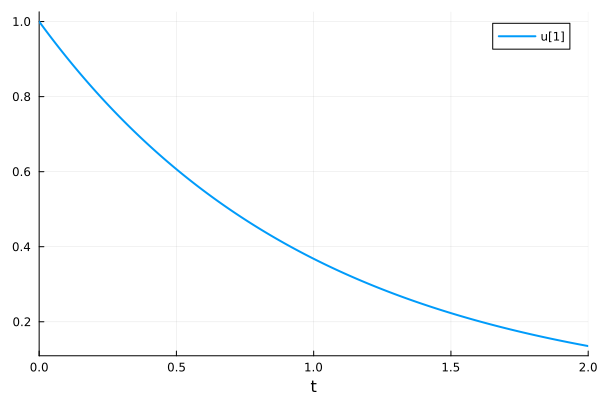

In [6]:
plot(sol)

### Three variables: The SIR model

The SIR model describes the spreading of an contagious disease can be described by the [SIR model](https://en.wikipedia.org/wiki/Compartmental_models_in_epidemiology):

$$
\begin{align}
\frac{d}{dt}S(t) &= - \beta S(t)I(t)  \\
\frac{d}{dt}I(t) &= \beta S(t)I(t)  - \gamma I(t)  \\
\frac{d}{dt}R(t) &= \gamma I(t)
\end{align}
$$

**State variables**

- $S(t)$ : the fraction of susceptible people
- $I(t)$ : the fraction of infectious people
- $R(t)$ : the fraction of recovered (or removed) people

**Parameters**

- $\beta$ : the rate of infection when susceptible and infectious people meet
- $\gamma$ : the rate of recovery of infectious people

In [7]:
using OrdinaryDiffEq
using Plots
Plots.default(linewidth=2)

SIR model (in-place form can save array allocations and thus faster)

In [8]:
function sir!(du, u, p, t)
    s, i, r = u
    β, γ = p
    v1 = β * s * i
    v2 = γ * i
    du[1] = -v1
    du[2] = v1 - v2
    du[3] = v2
    return nothing
end

sir! (generic function with 1 method)

In [9]:
p = (β=1.0, γ=0.3)
u0 = [0.99, 0.01, 0.00]
tspan = (0.0, 20.0)
prob = ODEProblem(sir!, u0, tspan, p)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 17-element Vector{Float64}:
  0.0
  0.08921318693905476
  0.3702862715172094
  0.7984257132319627
  1.3237271485666187
  1.991841832691831
  2.7923706947355837
  3.754781614278828
  4.901904318934307
  6.260476636498209
  7.7648912410433075
  9.39040980993922
 11.483861023017885
 13.372369854616487
 15.961357172044833
 18.681426667664056
 20.0
u: 17-element Vector{Vector{Float64}}:
 [0.99, 0.01, 0.0]
 [0.9890894703413342, 0.010634484617786016, 0.00027604504087978485]
 [0.9858331594901347, 0.012901496825852227, 0.0012653436840130785]
 [0.9795270529591532, 0.017282420996456258, 0.003190526044390597]
 [0.9689082167415561, 0.02463126703444545, 0.006460516223998508]
 [0.9490552312363142, 0.03827338797605378, 0.012671380787632141]
 [0.9118629475333939, 0.06347250098224964, 0.024664551484356558]
 [0.8398871089274511, 0.11078176031568547, 0.049331130756863524]
 [0.7075842068024722, 0.19166147882272844, 0.1007543143747994]
 [0.508146028721987

Visualize the solution

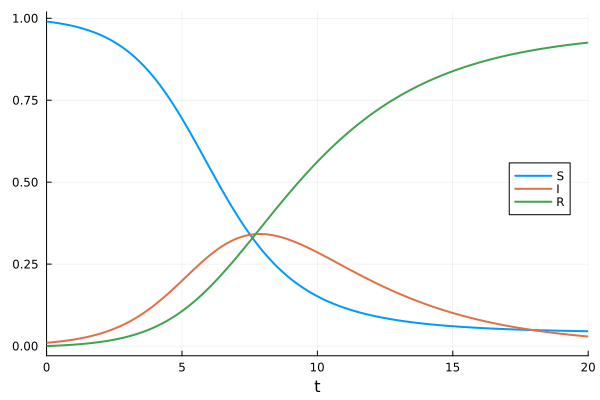

In [10]:
plot(sol, label=["S" "I" "R"], legend=:right)

## Using ModelingToolkit.jl (recommended)

[ModelingToolkit.jl](https://docs.sciml.ai/ModelingToolkit/stable/) is a high-level package for symbolic-numeric modeling and simulation in the Julia ecosystem.

In [11]:
using ModelingToolkit
using OrdinaryDiffEq
using Plots
Plots.default(linewidth=2)

### Exponential decay model

In [12]:
@independent_variables t    ## Time
@parameters λ               ## Decaying rate constant
@variables C(t)             ## Time and concentration
D = Differential(t)         ## Differential operator

Differential(t)

Define an ODE with equations

In [13]:
eqs = [D(C) ~ -λ * C]
@mtkbuild decaySys = ODESystem(eqs, t)

Model decaySys:
Equations (1):
  1 standard: see equations(decaySys)
Unknowns (1): see unknowns(decaySys)
  C(t)
Parameters (1): see parameters(decaySys)
  λ

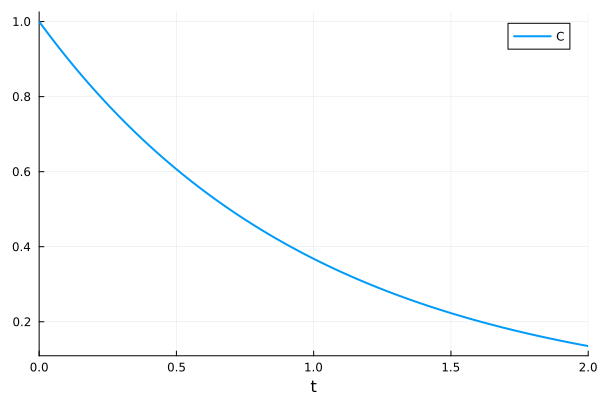

In [14]:
u0 = [C => 1.0]
p = [λ => 1.0]
tspan = (0.0, 2.0)

prob = ODEProblem(decaySys, u0, tspan, p)
sol = solve(prob)
plot(sol)

### SIR model

In [15]:
using OrdinaryDiffEq
using ModelingToolkit
using Plots
Plots.default(linewidth=2)

@independent_variables t
@parameters β γ
@variables s(t) i(t) r(t)
D = Differential(t)

eqs = [
    D(s) ~ -β * s * i,
    D(i) ~ β * s * i - γ * i,
    D(r) ~ γ * i
]

@mtkbuild sirSys = ODESystem(eqs, t)

Model sirSys:
Equations (3):
  3 standard: see equations(sirSys)
Unknowns (3): see unknowns(sirSys)
  s(t)
  i(t)
  r(t)
Parameters (2): see parameters(sirSys)
  β
  γ

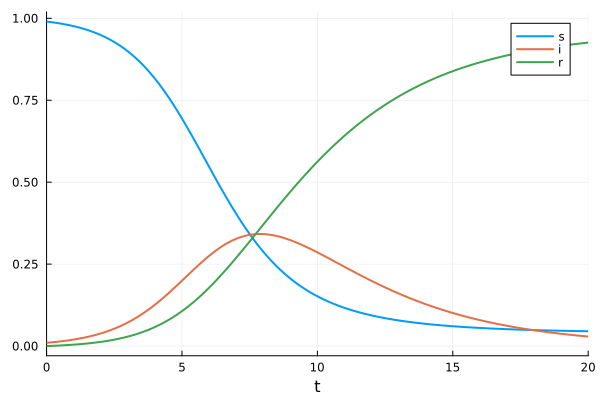

In [16]:
p = [β => 1.0, γ => 0.3]
u0 = [s => 0.99, i => 0.01, r => 0.00]
tspan = (0.0, 20.0)

prob = ODEProblem(sirSys, u0, tspan, p)
sol = solve(prob)

plot(sol)

### Lorenz system

The Lorenz system is a system of ordinary differential equations having chaotic solutions for certain parameter values and initial conditions. ([Wikipedia](https://en.wikipedia.org/wiki/Lorenz_system))

$$
\begin{align}
  \frac{dx}{dt} &= \sigma(y-x) \\
  \frac{dy}{dt} &= x(\rho - z) -y \\
  \frac{dz}{dt} &= xy - \beta z
\end{align}
$$

In [17]:
using OrdinaryDiffEq
using ModelingToolkit
using Plots
Plots.default(linewidth=2)

Building the model is wrapped in a function

In [18]:
function build_lorentz(; name)
    @parameters begin
        σ = 10.0
        ρ = 28.0
        β = 8 / 3
    end

    @independent_variables t
    @variables begin
        x(t) = 1.0    ## Independent variable (time)
        y(t) = 0.0    ## Independent variable (time)
        z(t) = 0.0    ## Independent variable (time)
    end

    D = Differential(t)

    eqs = [
        D(x) ~ σ * (y - x),
        D(y) ~ x * (ρ - z) - y,
        D(z) ~ x * y - β * z
    ]

    sys = ODESystem(eqs, t; name)
    return sys
end

build_lorentz (generic function with 1 method)

In [19]:
tspan = (0.0, 100.0)
@mtkbuild sys = build_lorentz()
prob = ODEProblem(sys, [], tspan, [])
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 1292-element Vector{Float64}:
   0.0
   3.5678604836301404e-5
   0.0003924646531993154
   0.003262408731175873
   0.009058076622686189
   0.01695647090176743
   0.027689960116420883
   0.041856352219618344
   0.060240411865493296
   0.08368541210909924
   ⋮
  99.43545175575305
  99.50217600300971
  99.56297541572351
  99.62622492183432
  99.69561088424294
  99.77387244562912
  99.86354266863755
  99.93826978918452
 100.0
u: 1292-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [0.9996434557625105, 0.0009988049817849058, 1.781434788799189e-8]
 [0.9961045497425811, 0.010965399721242457, 2.1469553658389193e-6]
 [0.9693591548287857, 0.0897706331002921, 0.00014380191884671585]
 [0.9242043547708632, 0.24228915014052968, 0.0010461625485930237]
 [0.8800455783133068, 0.43873649717821195, 0.003424260078582332]
 [0.8483309823046307, 0.6915629680633586, 0.008487625469885364]
 [0.8495036699348377, 1.0145426764822272, 0.01821209108471829]
 [0.91

x-y-z time-series

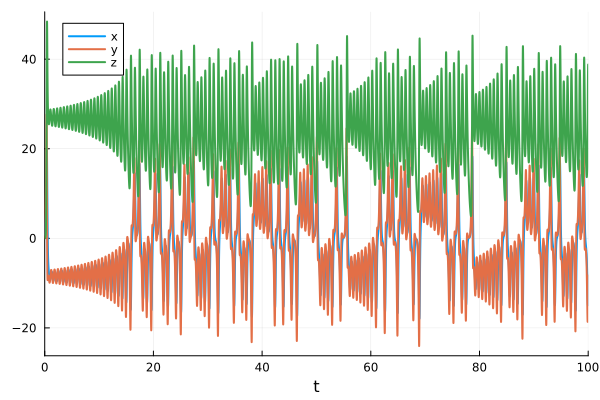

In [20]:
plot(sol)

y-t plot

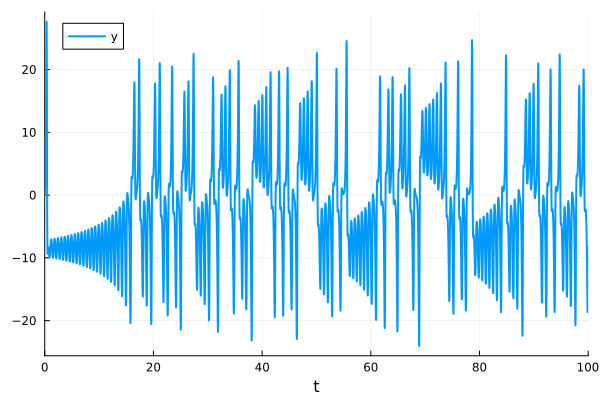

In [21]:
plot(sol, idxs=[sys.y])

`idxs=(sys.x, sys.y, sys.z)` makes a phase plot.

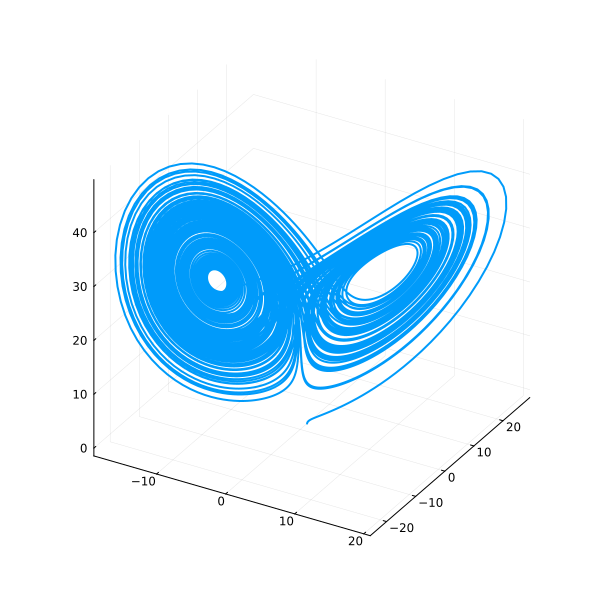

In [22]:
plot(sol, idxs=(sys.x, sys.y, sys.z), label=false, size=(600, 600))

## Saving simulation results

In [23]:
using DataFrames
using CSV

df = DataFrame(sol)
CSV.write("lorenz.csv", df)
rm("lorenz.csv")

## Catalyst.jl

[Catalyst.jl](https://github.com/SciML/Catalyst.jl) is a domain-specific language (DSL) package to simulate chemical reaction networks.

In [24]:
using OrdinaryDiffEq
using Catalyst
using Plots
Plots.default(linewidth=2)

### Exponential decay model

In [25]:
decay_rn = @reaction_network begin
    λ, C --> 0
end

Model ##ReactionSystem#242:
Unknowns (1): see unknowns(##ReactionSystem#242)
  C(t)
Parameters (1): see parameters(##ReactionSystem#242)
  λ

In [26]:
p = [:λ => 1.0]
u0 = [:C => 1.0]
tspan = (0.0, 2.0)

prob = ODEProblem(decay_rn, u0, tspan, p)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 8-element Vector{Float64}:
 0.0
 0.10001999200479662
 0.34208427066999536
 0.6553980136343391
 1.0312652525315806
 1.4709405856363595
 1.9659576669700232
 2.0
u: 8-element Vector{Vector{Float64}}:
 [1.0]
 [0.9048193287657775]
 [0.7102883621328676]
 [0.5192354400036404]
 [0.35655576576996556]
 [0.2297097907863828]
 [0.14002247272452764]
 [0.1353360028400881]

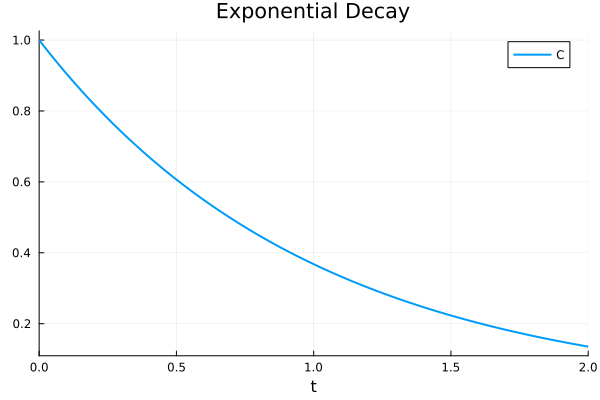

In [27]:
plot(sol, title="Exponential Decay")

### SIR model

In [28]:
sir_rn = @reaction_network begin
    β, S + I --> 2I
    γ, I --> R
end

Model ##ReactionSystem#250:
Unknowns (3): see unknowns(##ReactionSystem#250)
  S(t)
  I(t)
  R(t)
Parameters (2): see parameters(##ReactionSystem#250)
  β
  γ

Extract the symbols for later use

In [29]:
@unpack β, γ, S, I, R = sir_rn

p = [β => 1.0, γ => 0.3]
u0 = [S => 0.99, I => 0.01, R => 0.00]
tspan = (0.0, 20.0)

prob = ODEProblem(sir_rn, u0, tspan, p)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 17-element Vector{Float64}:
  0.0
  0.08921318693905476
  0.3702862715172094
  0.7984257132319627
  1.3237271485666187
  1.991841832691831
  2.7923706947355837
  3.754781614278828
  4.901904318934307
  6.260476636498209
  7.7648912410433075
  9.39040980993922
 11.483861023017885
 13.372369854616487
 15.961357172044833
 18.681426667664056
 20.0
u: 17-element Vector{Vector{Float64}}:
 [0.99, 0.01, 0.0]
 [0.9890894703413342, 0.010634484617786016, 0.00027604504087978485]
 [0.9858331594901347, 0.012901496825852227, 0.0012653436840130785]
 [0.9795270529591532, 0.017282420996456258, 0.003190526044390597]
 [0.9689082167415561, 0.02463126703444545, 0.006460516223998508]
 [0.9490552312363142, 0.03827338797605378, 0.012671380787632141]
 [0.9118629475333939, 0.06347250098224964, 0.024664551484356558]
 [0.8398871089274511, 0.11078176031568547, 0.049331130756863524]
 [0.7075842068024722, 0.19166147882272844, 0.1007543143747994]
 [0.508146028721987

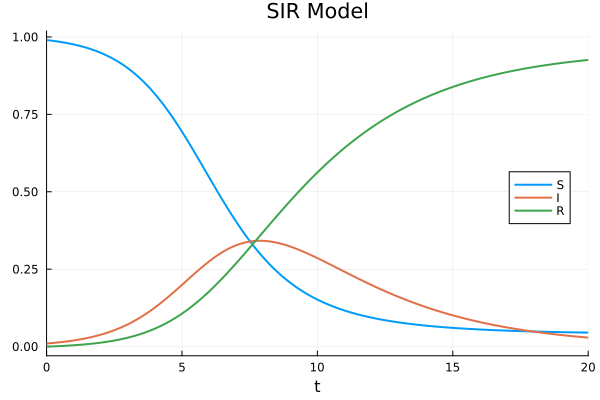

In [30]:
plot(sol, legend=:right, title="SIR Model")

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*